# Recherche Opérationnelle

## Introduction

Face aux défis climatiques actuels, la transition écologique impose de repenser en profondeur nos modes de fonctionnement industriels et logistiques. C'est dans cette dynamique que l'ADEME (Agence de l'Environnement et de la Maîtrise de l'Énergie) a lancé un appel à manifestation d'intérêt visant à promouvoir le développement de nouvelles solutions de mobilité intelligente. 

Le laboratoire **CesiCDP**, fort de son expertise en logistique multimodale, se positionne sur cet appel à projets avec un objectif clair : concevoir un outil algorithmique capable d'optimiser les tournées de livraison de marchandises. En minimisant les distances parcourues et en maximisant l'efficacité des flottes de véhicules, ce projet ambitionne de réduire significativement l'empreinte carbone et les coûts opérationnels liés au transport.

Ce document constitue le premier livrable de notre étude. Il a pour but de poser les fondations théoriques de notre solution en formalisant le problème logistique rencontré, en définissant les contraintes de terrain, et en démontrant la complexité mathématique inhérente à sa résolution.


# 1 - Modélisation

## 1.1 - Présentation du problème et de son contexte

### Contexte

Dans le cadre de l'appel à manifestation d'intérêt lancé par l'ADEME, le laboratoire CesiCDP se positionne pour concevoir de nouvelles solutions de mobilité multimodale intelligente. Face aux défis climatiques et à l'augmentation des flux de marchandises, l'enjeu est d'optimiser la logistique du transport (distribution, livraison, ramassage).

L'objectif environnemental est direct : limiter les déplacements inutiles et optimiser la gestion des ressources pour réduire drastiquement la consommation de carburant et les émissions polluantes.

#### Problématique

Le défi algorithmique central consiste à calculer une tournée sur un réseau routier permettant de relier un sous-ensemble défini de villes, puis de revenir au point de départ.

L’objectif est de minimiser la distance totale ou la durée globale des trajets effectués par une flotte de véhicules pour desservir un ensemble de clients. Bien que ce défi relève du Problème de **Tournées de Véhicules (VRP)**, un enjeu central de la logistique moderne, la réalité du terrain impose des défis supplémentaires.

### Contraintes Choisies

Pour garantir un démonstrateur réaliste et applicable à l'industrie, nous intégrons les contraintes suivantes, transformant le problème en un Problème de Tournées de Véhicules avec Capacités (CVRP) :
1. **Utilisation de plusieurs véhicules :** Il peut y avoir plusieurs sous-tournées plutôt qu'une seule grande tournée.
2. **Capacité des véhicules :** Si la contrainte précédente a été choisie, chaque véhicule a une capacité limite pour transporter des marchandises ou des passagers.



## 1.2 - Représentation formelle

Pour traiter ce problème algorithmiquement, nous le traduisons mathématiquement à l'aide de la théorie des graphes.

### Les Données (Le Réseau)

Le réseau routier est modélisé par un graphe complet orienté et pondéré $G = (V, E)$.

* **Sommets :** $V = \{v_0, v_1, \dots, v_n\}$ où $v_0$ représente le dépôt central et $V \setminus \{v_0\}$ l'ensemble des villes.
* **Arêtes :** $E$ représente l'ensemble des routes reliant les villes.
* **Coûts :** Chaque arête $(v_i, v_j)$ a un coût de trajet $c_{ij}$.
* **Demandes :** Chaque ville $v_i$ nécessite une quantité $q_i$. Le total des gens/colis à transporter est $Q_{total}$.
* **Véhicules :** Une flotte de $K$ véhicules (indexés par $k$), ayant chacun une capacité maximale $Q_{max}$.

### Variables de Décision

Nous définissons une variable binaire $x_{ijk}$ pour décider si une route est utilisée :

$$x_{ijk} \in \{0, 1\} \quad \forall i,j \in \{0, \dots, n\}, \forall k \in \{1, \dots, K\}$$

* $x_{ijk} = 1$ si le véhicule $k$ effectue le trajet de la ville $i$ vers la ville $j$.
* $x_{ijk} = 0$ sinon.

### Fonction Objectif

L'objectif est de minimiser le coût total des trajets effectués par l'ensemble de la flotte :

$$\text{Min } Z = \sum_{k=1}^{K} \sum_{i=0}^{n} \sum_{j=0}^{n} c_{ij} x_{ijk}$$

### Contraintes (SC)

1.  **Unicité de visite :** Chaque ville doit être visitée exactement une fois par un seul véhicule.
    $$\sum_{k=1}^{K} \sum_{i=0}^{n} x_{ijk} = 1 \quad \forall j \in \{1, \dots, n\}$$

2.  **Conservation du flux (Retour au dépôt) :** Tout véhicule arrivant à une ville (ou au dépôt) doit en repartir.
    $$\sum_{i=0}^{n} x_{i0k} - \sum_{j=0}^{n} x_{0jk} = 0 \quad \forall k \in \{1, \dots, K\}$$

3.  **CVRP :** Continuité entre les villes
    $$u_j \geq u_i + q_j - Q_{max}(1-x_{ij})$$

4.  **Capacité des véhicules :** Les colis/personnes transportés par le véhicule $k$ ne doivent pas excéder sa charge maximale $Q_{max}$.
    $$\sum_{i=0}^{n} \sum_{j=0}^{n} q_k x_{ijk} \leq Q_{max} \quad \forall k \in \{1, \dots, K\}$$

5.  **Activation des véhicules :** S'assurer que tous les véhicules partent au plus une fois du dépôt.
    $$\sum_{j=1}^{n} x_{0jk} \leq 1 \quad \forall k \in \{1, \dots, K\}$$




## 1.3 - Étude et Démonstration de la Complexité Théorique

L'étude des propriétés théoriques de notre modèle (le CVRP) révèle qu'il s'agit d'un problème combinatoire complexe combinant deux dimensions difficiles : l'ordre de visite (Parcours) et la répartition des charges dans une flotte limitée (Bin Packing).

### Version décisionnelle

Pour évaluer la complexité, nous définissons le problème de décision associé : \\
*Existe-t-il un ensemble de tournées valides (commençant au dépôt, visitant chaque ville une fois sans dépasser la capacité $Q$) dont le coût total est $\leq L$ ?*

### Appartenance à la classe NP

Un problème est dans la classe NP si la validité d'une solution candidate (certificat) peut être vérifiée en temps polynomial par rapport à la taille de l'entrée $n$. 

Pour un ensemble de parcours donné, nous pouvons :
- Vérifier que chaque ville est visitée exactement une fois (Temps $\mathcal{O}(n)$).
- Sommer les demandes $q_i$ par véhicule pour vérifier que le total est $\leq Q$ (Temps $\mathcal{O}(n)$).
- Additionner les coûts $c_{ij}$ pour vérifier que la somme est $\leq L$ (Temps $\mathcal{O}(n)$).


Algorithme de vérification de solution:
```
Variables:
    Liste sommetsVisites
    Réel tempsTotal <- 0
    Entier n <- taille(solution)

Début:
    # 1. Vérification de la complétude
    Si n != G.nombreSommets():
        Renvoyer Faux
    Fin Si

    Pour i allant de 0 à n - 1:
        Sommet actuel <- solution[i]

        # 2. Vérifier si le sommet existe dans le graphe et n'est pas un doublon
        Si NON G.existeSommet(actuel) OU actuel appartient à sommetsVisites:
            Renvoyer Faux
        Fin Si
        sommetsVisites.ajouter(actuel)

        # 3. Calcul du temps et continuité du chemin
        Sommet suivant <- solution[i + 1]
        Arrete arc <- G.trouverArrete(actuel, suivant)

        Si estVide(arc):
            Renvoyer Faux
        Sinon:
            tempsTotal <- tempsTotal + arc.poids
        Fin Si
    Fin Pour

    # 4. Vérification de la contrainte de temps
    Si tempsTotal > tempsMax:
        Renvoyer Faux
    Fin Si

    Renvoyer Vrai
Fin
```

Les vérifications s'effectuant en temps polynomial, le problème appartient bien à NP.

### Démonstration de la NP-difficulté (par restriction)

Pour prouver formellement la NP-difficulté, nous démontrons par restriction que notre problème contient un cas particulier déjà connu comme NP-difficile : le Problème du Voyageur de Commerce (TSP).

- **Problème source :** Le TSP est prouvé NP-difficile.
- **Réduction :** Fixons les paramètres de notre problème avec $K = 1$ véhicule, et une capacité $Q$ suffisamment grande pour couvrir la somme de toutes les demandes ($\sum q_i \leq Q$).
- **Équivalence :** Dans ce cas de figure, la contrainte de capacité $Q$ disparaît de fait. Le problème se réduit exactement à trouver le cycle hamiltonien de coût minimal traversant toutes les villes, ce qui est la définition stricte du TSP.
- **Conclusion :** Puisque notre modèle peut se réduire au TSP, il est au moins aussi difficile à résoudre. Il est donc NP-difficile.

#### Conclusion sur la complexité

Étant simultanément dans NP et NP-difficile, notre problème d'optimisation de tournées avec capacités est **s**. Il est donc hautement improbable qu'un algorithme exact puisse le résoudre en temps polynomial pour de grandes instances de réseaux routiers, justifiant l'utilisation future de méthodes heuristiques ou méta-heuristiques.




# 2 - Étude expérimentale

## 2.0 - préparation
Installation et importation des libréries nécessaires


In [84]:
%pip install matplotlib pulp ipywidgets IPython numpy networkx

Note: you may need to restart the kernel to use updated packages.


In [85]:
import random
import time
import matplotlib.pyplot as plt
from collections import deque
from pulp import *
from ipywidgets import IntProgress
from IPython.display import display
import statistics
import numpy as np
import networkx as nx
from matplotlib.lines import Line2D
import math
from math import trunc

## 2.1 génerer des instances aléatoires

Pour commencer nous allons mettre en place les fontions principales utilisées sur le reste du document de l'étude.

Ces fonctions vont nous permettre de generer automatiquement des instance du problème aléatoirement  ainsi que calcalculer notre fonction objetif, generer un solution au hazard.
afficher une solution sous forme de text ou visuelment sous forme de graphe

In [86]:
def generer_instance(n = None,nb_vehicules = None , n_max = 15,nb_vehicules_max = 10, max_capacite_coeff = 2.5):


    n = random.randint(5,n_max) if n is None else int(n)
    nb_vehicules = random.randint(2,nb_vehicules_max) if nb_vehicules is None else int(nb_vehicules)



    taille = n + 1
    matrice = [[0] * taille for _ in range(taille)]

    for i in range(taille):
        for j in range(i + 1, taille):
            dist = random.randint(5,50) if random.random() > 0.1 else INF
            matrice[i][j] = dist
            matrice[j][i] = dist

    demandes = [0]
    total_colis = 0
    for _ in range(n):
        d = random.randint(1, 10)
        demandes.append(d)
        total_colis += d
    capacite_min = math.ceil(total_colis / nb_vehicules)
    capacite_max = int(capacite_min * random.uniform(1.1, max_capacite_coeff))

    print(f"\n--- Instance générée ---")
    print(f"Total colis à livrer : {total_colis}")
    print(f"Capacité par véhicule : {capacite_max}")

    capacite_max = max(capacite_max, max(demandes[1:]))
    return n, nb_vehicules, matrice, demandes, capacite_max

def distance_total(solution, matrice):

    z = 0
    for tournee in solution:

        for i in range(len(tournee) - 1):
            z += matrice[tournee[i]][tournee[i+1]]
    return z

def generer_random_solution(n, nb_vehicules, demandes, capacite_max):
    villes = list(range(1, n + 1))
    random.shuffle(villes)

    solution = []
    tournee_actuelle = [0]
    charge_actuelle = 0

    for ville in villes:
        demande_ville = demandes[ville]


        if charge_actuelle + demande_ville <= capacite_max:
            tournee_actuelle.append(ville)
            charge_actuelle += demande_ville
        else:
            tournee_actuelle.append(0)
            solution.append(tournee_actuelle)
            tournee_actuelle = [0, ville]
            charge_actuelle = demande_ville

    tournee_actuelle.append(0)
    solution.append(tournee_actuelle)

    if len(solution) > nb_vehicules:
        print(f"Attention : L'instance nécessite {len(solution)} véhicules, mais seulement {nb_vehicules} sont autorisés.")
        return None

    while len(solution) < nb_vehicules:
        solution.append([0, 0])

    return solution

def afficher_resultats(titre, solution, matrice, demandes, capacite_max):
    distance = distance_total(solution, matrice)
    print(f"\n{'='*15} {titre} {'='*15}")
    print(f"DISTANCE TOTALE : {distance}")
    print(f"VECTEUR SOLUTION : {solution}")
    print("-" * (32 + len(titre)))

    for k in range(len(solution)):

        route_brute = solution[k]
        route_propre = []
        for i, ville in enumerate(route_brute):
            if i == 0 or ville != route_brute[i-1]:
                route_propre.append(ville)

        charge_camion = sum(demandes[v] for v in route_propre)
        print(f"Camion {k} [Charge {charge_camion}/{capacite_max}] : {' -> '.join(map(str, route_propre))}")

def visualiser_probleme(n, matrice, demandes, solution=None, titre="Visualisation CVRP"):
    G = nx.Graph()

    for i in range(n + 1):
        G.add_node(i)

    pos = nx.spring_layout(G)


    fig = plt.figure(figsize=(12, 8), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    plt.title(titre, fontweight='bold')

    labels_noeuds = {0: "Dépôt\n(q=0)"}
    for i in range(1, n + 1):
        labels_noeuds[i] = f"v{i}\n(q={demandes[i]})"

    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='firebrick', node_shape='s', node_size=2000)
    nx.draw_networkx_nodes(G, pos, nodelist=list(range(1, n+1)), node_color='teal', node_size=1500)

    nx.draw_networkx_labels(G, pos, labels=labels_noeuds, font_size=9, font_weight="bold", font_color='white')

    elements_legende = [
        Line2D([0], [0], marker='s', color='w', label='Dépôt', markerfacecolor='firebrick', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='Villes', markerfacecolor='teal', markersize=12)
    ]

    if solution:

        couleurs = [
            '#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4',
            '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324',
            '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075',
            '#a9a9a9', '#000000'
        ]
        etiquettes_aretes = {}

        for k, tournee in enumerate(solution):
            if len(tournee) <= 2:
                continue

            couleur_camion = couleurs[k % len(couleurs)]
            edges_tournee = []

            for i in range(len(tournee) - 1):
                u, v = tournee[i], tournee[i+1]
                if u != v:
                    edges_tournee.append((u, v))
                    etiquettes_aretes[(u, v)] = matrice[u][v]

            nx.draw_networkx_edges(
                G, pos,
                edgelist=edges_tournee,
                edge_color=couleur_camion,
                width=2.5,
                arrows=True,
                arrowstyle='->',
                arrowsize=20
            )

            elements_legende.append(Line2D([0], [0], color=couleur_camion, lw=2.5, label=f'Camion {k+1}'))

        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=etiquettes_aretes,
            font_color='red',
            font_size=10,
            font_weight='bold',
            label_pos=0.3,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
        )

    else:

        edges_base = []
        etiquettes_base = {}

        for i in range(n + 1):

            for j in range(i + 1, n + 1):
                dist = matrice[i][j]
                if dist != 0 and dist != INF:
                    edges_base.append((i, j))
                    etiquettes_base[(i, j)] = dist


        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges_base,
            edge_color='gray',
            width=1,
            alpha=0.3
        )


        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=etiquettes_base,
            font_color='dimgray',
            font_size=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6)
        )

    plt.legend(
        handles=elements_legende,
        loc='upper left',
        facecolor='white',
        framealpha=1.0,
        edgecolor='black',
        fontsize=10,
        labelcolor='black'

    )

    plt.axis('off')
    plt.tight_layout()
    plt.show()

def afficher_courbe(courants, meilleurs_courants, title):
    plt.figure(figsize=(10, 5))

    plt.plot(range(len(courants)), courants, label="Solution courante", color="tab:blue", alpha=0.7)
    plt.plot(range(len(meilleurs_courants)), meilleurs_courants, label="Meilleure solution", color="tab:orange", linewidth=2.5)

    plt.xlabel("Nombre d'itérations", fontsize=10)
    plt.ylabel("Valeur", fontsize=10)
    plt.title(title, fontsize=18)
    plt.legend()
    plt.grid(True)
    plt.show();
    
    
INF = 9999999999


## 2.2 verifier la solutions
Une fonction pour verifier si la solution respecte toutes les contraintes

In [87]:
def verifier_solution(solution, matrice, demandes, capacite_max):
    n = len(matrice) - 1
    villes_visitees = []

    for k, tournee in enumerate(solution):

        if len(tournee) <= 2:
            continue

        if tournee[0] != 0 or tournee[-1] != 0:
            print(f"Erreur Véhicule {k} : Doit commencer et finir au dépôt (0).")
            return False

        charge_vehicule = 0
        for i in range(len(tournee) - 1):
            u = tournee[i]
            v = tournee[i+1]


            if matrice[u][v] == INF:
                print(f"Erreur : Trajet impossible entre {u} et {v}.")
                return False


            if v != 0:
                villes_visitees.append(v)
                charge_vehicule += demandes[v]

        if charge_vehicule > capacite_max:
            print(f"Erreur Véhicule {k} : Capacité dépassée ({charge_vehicule} > {capacite_max}).")
            return False

    if sorted(villes_visitees) != list(range(1, n + 1)):
        print(f"Erreur : Les villes visitées {sorted(villes_visitees)} ne correspondent pas à la liste attendue.")
        return False

    return True


# 3 - résolutions

Pour trouver une soultion au problème nous allons aborder plusieurs aproches.
nous allons commencer par essayer 3 algorithmes différent.
l'algorithme tabu, l'algorithem genetique et l'algorithme ACO (Ant Colony optimization)

## 3.1 Cas d'étude
on comence par generes un cas avec le quel on pourra tester nos solution. Les arrêtes avec un poid infinit représent un route inexistante entre 2 villes.


--- Instance générée ---
Total colis à livrer : 57
Capacité par véhicule : 23


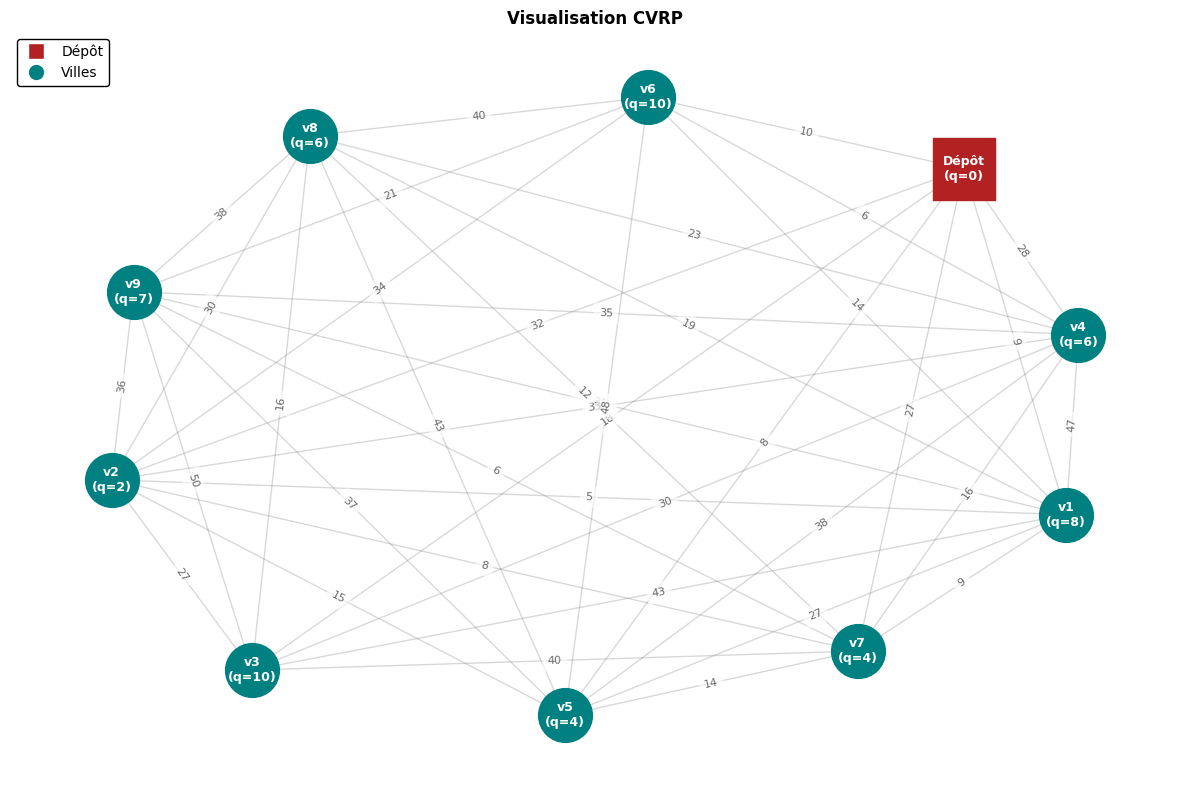

In [88]:
n, nb_vehicules, matrice, demandes, capacite_max = generer_instance()


visualiser_probleme(n,matrice,demandes)

## 3.2 Résolution rechcerche tabu
### Principe

La Recherche Tabou est une méthode de recherche locale trajectoire. Son point fort est sa capacité à sortir des optima locaux en acceptant temporairement des solutions moins bonnes.

Pour le CVRP, l'algorithme procède ainsi :

- Initialisation : Partir d'une solution initiale (souvent générée par un algorithme glouton ou aléatoire).

- Exploration du voisinage : À chaque itération, l'algorithme génère des solutions voisines en appliquant des mouvements simples (ex: déplacer un client d'une route à une autre ou échanger deux clients).

- Mécanisme de mémoire (Liste Tabou) : Pour éviter de tourner en rond (cycles), les derniers mouvements effectués sont enregistrés dans une "liste tabou" et interdits pendant un certain nombre d'itérations T.

- Sélection du meilleur voisin : On choisit le meilleur voisin qui n'est pas dans la liste tabou, même s'il dégrade la distance totale.

- Critère d'aspiration : Si un mouvement tabou produit une solution meilleure que la meilleure solution trouvée depuis le début, on lève l'interdiction.

### Implémentation

In [89]:
def voisinage(solution):
    for i in range(0, len(solution)):
        for j in range(i + 1, len(solution)):
            voisin = solution[:]
            voisin[i], voisin[j] = voisin[j], voisin[i]
            yield voisin


def recherche_tabou(solution_initiale, matrice, demandes, capacite_max, taille_tabou, iter_max):
    seq_courante = [v for tournee in solution_initiale for v in tournee if v != 0]

    nb_iter = 0
    liste_tabou = deque([], maxlen=taille_tabou)

    meilleure_globale_seq = seq_courante[:]
    valeur_meilleure_globale = distance_total([[0] + t + [0] for t in split_solution(seq_courante, demandes, capacite_max)], matrice)

    historique_courant = []
    historique_meilleur_global = []

    while nb_iter < iter_max:
        nb_iter += 1
        valeur_meilleure_voisin = INF
        meilleure_voisin = None

        for voisin in voisinage(seq_courante):
            routes_voisin = [[0] + t + [0] for t in split_solution(voisin, demandes, capacite_max)]
            val_v = distance_total(routes_voisin, matrice)
            v_tuple = tuple(voisin)

            if v_tuple not in liste_tabou or val_v <= valeur_meilleure_globale or meilleure_voisin is None:
                if val_v <= valeur_meilleure_voisin or meilleure_voisin is None:
                    valeur_meilleure_voisin = val_v
                    meilleure_voisin = voisin



        seq_courante = meilleure_voisin
        liste_tabou.append(tuple(meilleure_voisin))

        if valeur_meilleure_voisin < valeur_meilleure_globale:
            meilleure_globale_seq = meilleure_voisin[:]
            valeur_meilleure_globale = valeur_meilleure_voisin
            nb_iter = 0
        else:
            nb_iter += 1

        historique_courant.append(valeur_meilleure_voisin)
        historique_meilleur_global.append(valeur_meilleure_globale)

    tournees = split_solution(meilleure_globale_seq, demandes, capacite_max)
    meilleure_globale_seq = [[0] + t + [0] for t in tournees]
    while len(meilleure_globale_seq) < len(solution_initiale):
        meilleure_globale_seq.append([0, 0])

    return meilleure_globale_seq, historique_courant, historique_meilleur_global

def split_solution(sequence, demandes, capacite_max):
    tournees = []
    tournee_actuelle = []
    charge_actuelle = 0

    for ville in sequence:
        if charge_actuelle + demandes[ville] <= capacite_max:
            tournee_actuelle.append(ville)
            charge_actuelle += demandes[ville]
        else:
            tournees.append(tournee_actuelle)
            tournee_actuelle = [ville]
            charge_actuelle = demandes[ville]

    if tournee_actuelle:
        tournees.append(tournee_actuelle)
    return tournees

### résultat


=============== MEILLEURE SOLUTION GLOBALE ===============
DISTANCE TOTALE : 186
VECTEUR SOLUTION : [[0, 1, 2, 5, 0], [0, 6, 9, 7, 0], [0, 3, 8, 4, 0], [0, 0], [0, 0], [0, 0]]
----------------------------------------------------------
Camion 0 [Charge 14/23] : 0 -> 1 -> 2 -> 5 -> 0
Camion 1 [Charge 21/23] : 0 -> 6 -> 9 -> 7 -> 0
Camion 2 [Charge 22/23] : 0 -> 3 -> 8 -> 4 -> 0
Camion 3 [Charge 0/23] : 0
Camion 4 [Charge 0/23] : 0
Camion 5 [Charge 0/23] : 0


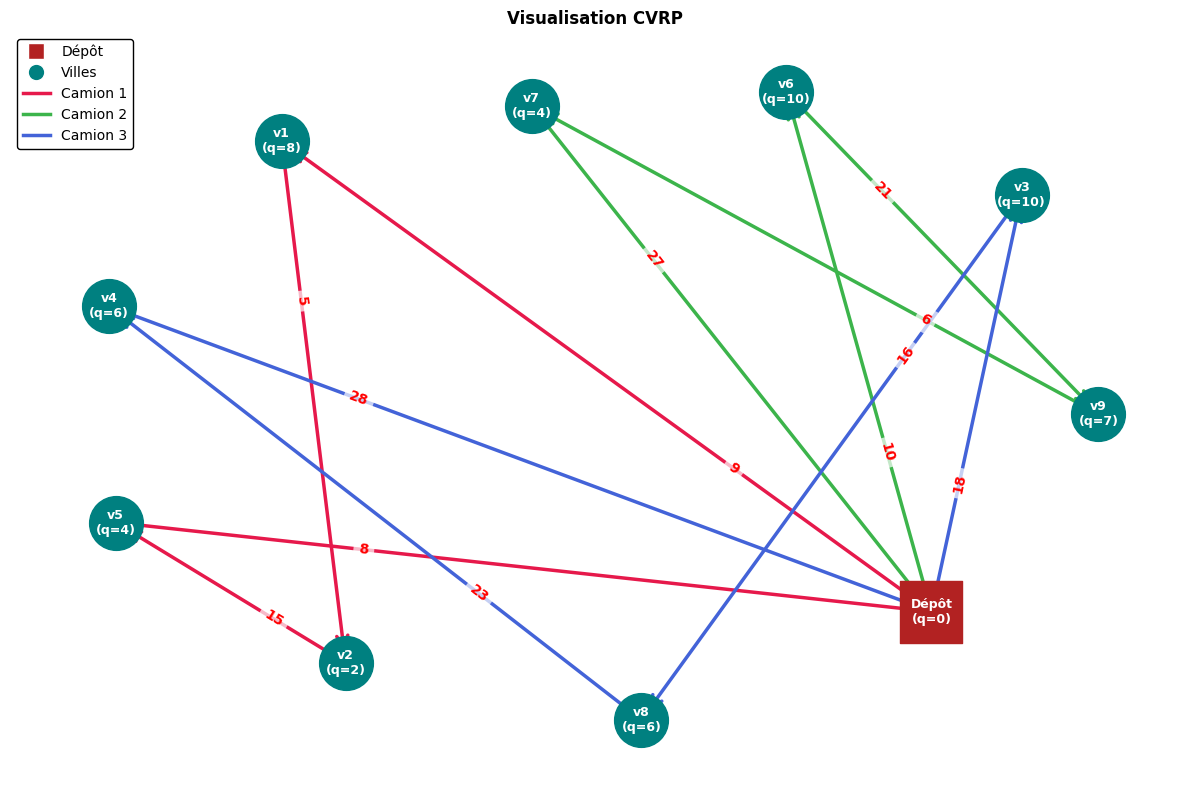

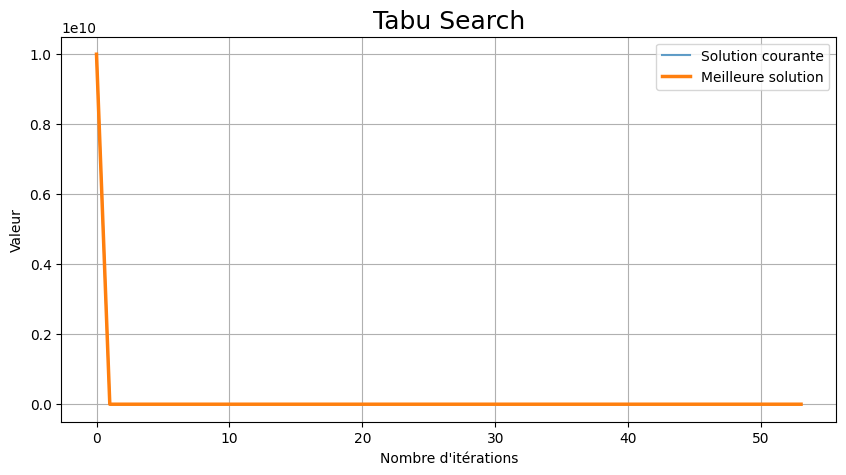

In [90]:
random.seed(a=3)


sol_depart = generer_random_solution(n, nb_vehicules,demandes,capacite_max)
solution_trouvee,historique_courant,historique_meilleur_global = recherche_tabou(sol_depart, matrice, demandes, capacite_max, taille_tabou=10, iter_max=100)

afficher_resultats("MEILLEURE SOLUTION GLOBALE", solution_trouvee, matrice, demandes, capacite_max)
visualiser_probleme(n, matrice, demandes,solution_trouvee)

afficher_courbe(historique_courant, historique_meilleur_global, "Tabu Search")

## 3.3 résolution algorithme génétique

### Principe

L'algorithme génétique s'inspire de la théorie de l'évolution de Darwin. Il fait évoluer une population de solutions (individus) sur plusieurs générations en utilisant des opérateurs biologiques de sélection, de croisement et de mutation.

Dans le cadre du CVRP, le processus suit ces étapes clés :

1. **Codage (Chromosome)** : Une solution est représentée par une séquence de clients.
2. **Évaluation (Fitness)** : La qualité d'un individu est inversement proportionnelle à la distance totale parcourue :
$$f(x) = \frac{1}{\sum \text{Distances}}$$
3. **Sélection** : On choisit les parents qui vont se reproduire, en privilégiant les plus adaptés (méthode de la roulette ou tournoi).
4. **Croisement (Crossover)** : On combine deux parents pour créer un enfant.
5. **Mutation** : On modifie aléatoirement un individu (par exemple en inversant deux gènes) pour maintenir la diversité génétique et éviter une convergence prématurée vers un optimum local.



### Paramètres
- `taille_pop` : Nombre d'individus dans la population.
- `generations` : Nombre de cycles d'évolution.
- `p_mutation` : Probabilité qu'un gène subisse une mutation (souvent faible, entre 0.01 et 0.1).

### Implémentation


In [91]:
def croisement(p1, p2, n, nb_vehicules, demandes, capacite_max,p_mutation = 0.1):
    villes_p1 = [v for route in p1 for v in route if v != 0]
    villes_p2 = [v for route in p2 for v in route if v != 0]



    cut = random.randint(1, n-1)
    enfant_villes = villes_p1[:cut]


    for v in villes_p2:
        if v not in enfant_villes:
            enfant_villes.append(v)

    if random.random() < p_mutation: enfant_villes = muter_solution(enfant_villes)

    solution = []
    route = [0]
    charge = 0
    for v in enfant_villes:
        if charge + demandes[v] <= capacite_max:
            route.append(v)
            charge += demandes[v]
        else:
            route.append(0)
            solution.append(route)
            route = [0, v]
            charge = demandes[v]
    route.append(0)
    solution.append(route)
    while len(solution) < nb_vehicules: solution.append([0, 0])

    return solution

In [92]:
def muter_solution(solution_enfant):

    if len(solution_enfant) < 2: return solution_enfant

    i, j = random.sample(range(len(solution_enfant)), 2)
    solution_enfant[i], solution_enfant[j] = solution_enfant[j], solution_enfant[i]

    return solution_enfant

In [93]:
def algorithme_genetique(n, nb_vehicules, matrice, demandes, capacite_max, taille_pop=50, generations=100, p_mutation=0.1):

    population = []
    meilleur_par_generation = []
    for _ in range(taille_pop):
        sol = generer_random_solution(n, nb_vehicules, demandes, capacite_max)
        if sol: population.append(sol)


    for gen in range(generations):
        population = sorted(population, key=lambda s: distance_total(s, matrice))

        nouvelle_population = population[:2]
        meilleur_par_generation.append(distance_total(nouvelle_population[0],matrice))

        while len(nouvelle_population) < taille_pop:

            parent1 = selection_tournoi(population, matrice)
            parent2 = selection_tournoi(population, matrice)

            enfant = croisement(parent1, parent2, n, nb_vehicules, demandes, capacite_max,p_mutation)


            if enfant: nouvelle_population.append(enfant)

        population = nouvelle_population
        if gen % 10 == 0:
            best_dist = distance_total(population[0], matrice)
            print(f"Génération {gen} : Meilleure distance = {best_dist}")

    return population[0],meilleur_par_generation

def selection_tournoi(population, matrice, k=3):
    participants = random.sample(population, k)
    return min(participants, key=lambda s: distance_total(s, matrice))

## 2.3.3 Résultat

Génération 0 : Meilleure distance = 293
Génération 10 : Meilleure distance = 224
Génération 20 : Meilleure distance = 204
Génération 30 : Meilleure distance = 204
Génération 40 : Meilleure distance = 186
Génération 50 : Meilleure distance = 186
Génération 60 : Meilleure distance = 186
Génération 70 : Meilleure distance = 186
Génération 80 : Meilleure distance = 186
Génération 90 : Meilleure distance = 186

=============== algorithme genetique ===============
DISTANCE TOTALE : 186
VECTEUR SOLUTION : [[0, 7, 9, 6, 0], [0, 1, 2, 5, 0], [0, 3, 8, 4, 0], [0, 0], [0, 0], [0, 0]]
----------------------------------------------------
Camion 0 [Charge 21/23] : 0 -> 7 -> 9 -> 6 -> 0
Camion 1 [Charge 14/23] : 0 -> 1 -> 2 -> 5 -> 0
Camion 2 [Charge 22/23] : 0 -> 3 -> 8 -> 4 -> 0
Camion 3 [Charge 0/23] : 0
Camion 4 [Charge 0/23] : 0
Camion 5 [Charge 0/23] : 0
[293, 277, 225, 225, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 212, 212, 204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 204, 2

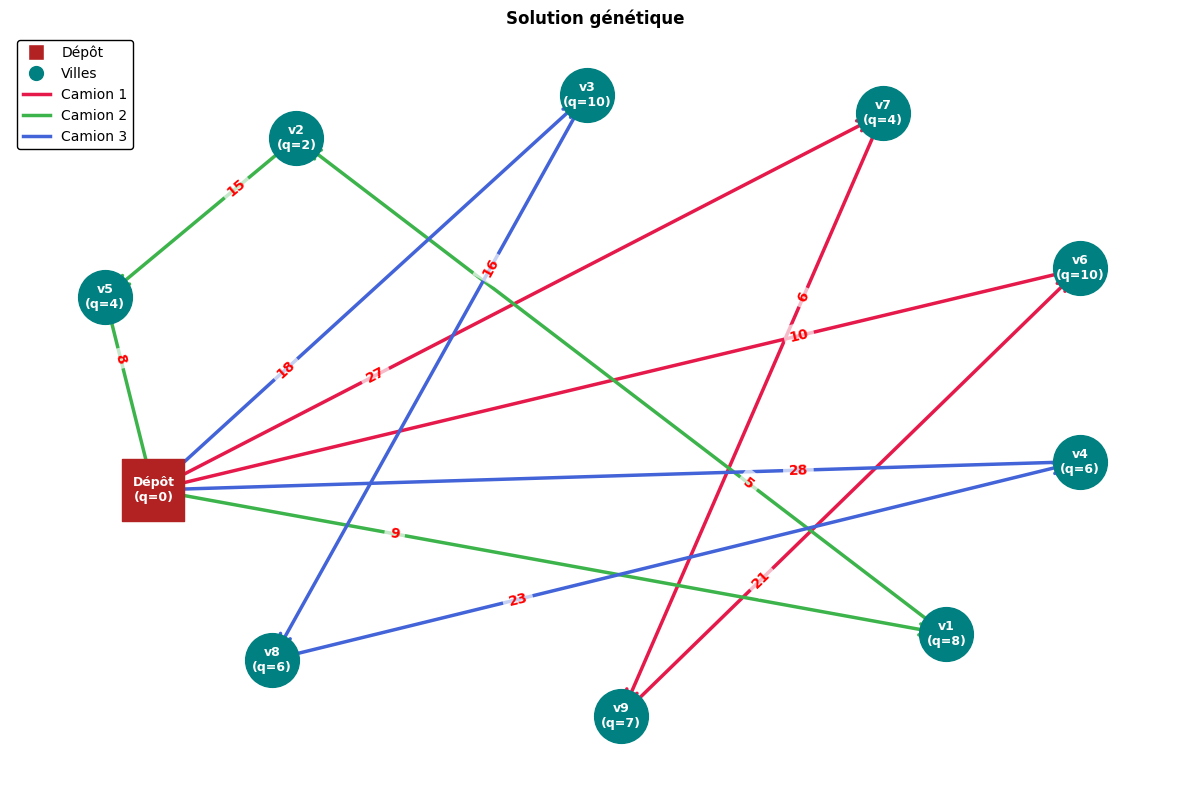

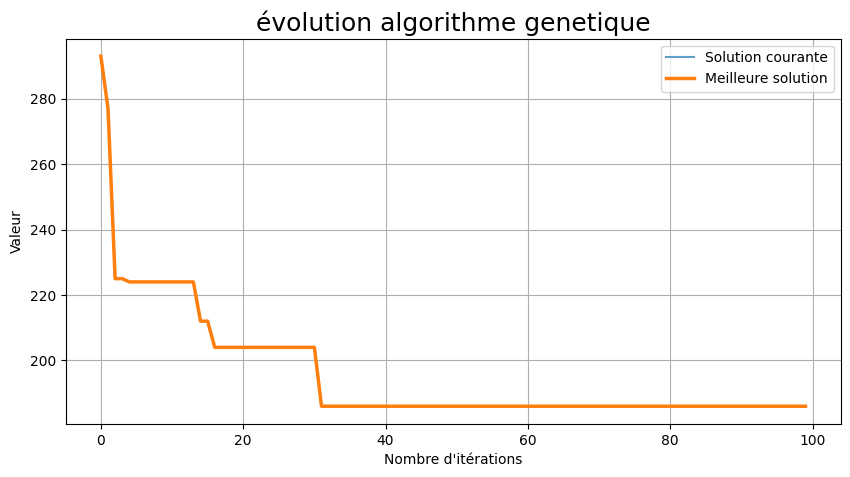

In [94]:

solution, historique =algorithme_genetique(n, nb_vehicules, matrice, demandes, capacite_max)
afficher_resultats("algorithme genetique",solution,matrice,demandes,capacite_max)

print(historique)
visualiser_probleme(n,matrice,demandes,solution,"Solution génétique")
afficher_courbe(historique,historique,"évolution algorithme genetique")


## 2.4 Résolution par Colonies de Fourmis (Ant Colony Optimization)

Ce notebook implémente un troisième algorithme pour le CVRP : **Ant Colony Optimization (ACO)**.

### Principe

ACO est une métaheuristique inspirée du comportement des fourmis réelles : elles déposent des phéromones sur leurs chemins, et les pistes courtes voient leurs phéromones s'accumuler plus vite, créant une convergence collective vers les meilleurs trajets.

Pour le CVRP, chaque *fourmi artificielle* construit une solution complète (un ensemble de tournées) de la manière suivante :

1. Partir du dépôt avec un véhicule vide.
2. Choisir la prochaine ville non visitée selon la règle probabiliste :
$$P(i \to j) = \frac{[\tau_{ij}]^{\alpha} \cdot [\eta_{ij}]^{\beta}}{\sum_{l \in \text{faisable}} [\tau_{il}]^{\alpha} \cdot [\eta_{il}]^{\beta}}$$
   où $\tau_{ij}$ est le niveau de phéromone et $\eta_{ij} = 1/c_{ij}$ est l'information heuristique (inverse de la distance).
3. Si aucune ville ne rentre dans la capacité restante, retour au dépôt et ouverture d'un nouveau véhicule.
4. Continuer jusqu'à avoir visité toutes les villes.

À chaque itération, les phéromones s'évaporent ($\tau \leftarrow (1-\rho)\tau$) puis les fourmis déposent une quantité proportionnelle à la qualité de leur solution ($\Delta\tau = Q/L$, où $L$ est la distance totale).

### Paramètres
- $\alpha$ : poids des phéromones (exploitation du savoir accumulé)
- $\beta$ : poids de l'heuristique (attirance des villes proches)
- $\rho$ : taux d'évaporation (entre 0 et 1)
- $Q$ : constante de dépôt
- `n_fourmis` : nombre de fourmis par itération
- `n_iter` : nombre d'itérations

### Implémentation d'ACO

#### Construction d'une solution par une fourmi

Une fourmi construit une solution en enchaînant des tournées. Pour chaque ville à visiter, elle calcule la probabilité de chaque ville candidate (non visitée, rentrant dans la capacité restante, accessible) et tire au sort.

In [95]:
def _construire_solution_fourmi(matrice, demandes, capacite_max, nb_vehicules, pheromones, alpha, beta):

    n = len(matrice) - 1
    non_visitees = set(range(1, n + 1))
    solution = []
    vehicules_utilises = 0

    while non_visitees and vehicules_utilises < nb_vehicules:
        tournee = [0]
        charge = 0
        courant = 0

        while True:

            candidates = [
                j for j in non_visitees
                if charge + demandes[j] <= capacite_max and matrice[courant][j] != INF
            ]
            if not candidates:
                break


            poids = []
            for j in candidates:
                tau = pheromones[courant][j] ** alpha
                eta = (1.0 / matrice[courant][j]) ** beta
                poids.append(tau * eta)

            total = sum(poids)
            if total == 0:
                choix = random.choice(candidates)
            else:
                r = random.random() * total
                cumul = 0
                choix = candidates[-1]
                for j, p in zip(candidates, poids):
                    cumul += p
                    if cumul >= r:
                        choix = j
                        break

            tournee.append(choix)
            charge += demandes[choix]
            non_visitees.remove(choix)
            courant = choix


        if matrice[courant][0] == INF:
            return None
        tournee.append(0)
        solution.append(tournee)
        vehicules_utilises += 1

    if non_visitees:
        return None


    while len(solution) < nb_vehicules:
        solution.append([0, 0])

    return solution

#### Boucle principale ACO

À chaque itération : toutes les fourmis construisent une solution, on évapore les phéromones, puis on dépose en fonction de la qualité (règle *Ant System* avec renforcement élitiste de la meilleure solution globale).

In [96]:
def aco_cvrp(matrice, demandes, capacite_max, nb_vehicules,
             n_fourmis=20, n_iter=100,
             alpha=1.0, beta=3.0, rho=0.1, Q=100.0,
             tau_0=1.0, elitisme=True, historique=False):

    taille = len(matrice)
    pheromones = [[tau_0] * taille for _ in range(taille)]

    meilleure_solution = None
    meilleure_distance = INF
    hist_courante = []
    hist_meilleure = []

    for it in range(n_iter):
        solutions_iter = []
        for _ in range(n_fourmis):
            sol = _construire_solution_fourmi(
                matrice, demandes, capacite_max, nb_vehicules,
                pheromones, alpha, beta
            )
            if sol is None:
                continue
            dist = distance_total(sol, matrice)
            solutions_iter.append((sol, dist))
            if dist < meilleure_distance:
                meilleure_distance = dist
                meilleure_solution = sol

        for i in range(taille):
            for j in range(taille):
                pheromones[i][j] *= (1 - rho)

        for sol, dist in solutions_iter:
            depot = Q / dist if dist > 0 else 0
            for tournee in sol:
                for k in range(len(tournee) - 1):
                    u, v = tournee[k], tournee[k+1]
                    pheromones[u][v] += depot
                    pheromones[v][u] += depot

        if elitisme and meilleure_solution is not None:
            depot_elite = Q / meilleure_distance
            for tournee in meilleure_solution:
                for k in range(len(tournee) - 1):
                    u, v = tournee[k], tournee[k+1]
                    pheromones[u][v] += depot_elite
                    pheromones[v][u] += depot_elite

        if historique:
            dist_iter = min((d for _, d in solutions_iter), default=INF)
            hist_courante.append(dist_iter)
            hist_meilleure.append(meilleure_distance)

    if historique:
        return meilleure_solution, meilleure_distance, hist_courante, hist_meilleure
    return meilleure_solution, meilleure_distance

### Résultat


=============== MEILLEURE SOLUTION ===============
DISTANCE TOTALE : 206
VECTEUR SOLUTION : [[0, 3, 8, 4, 0], [0, 6, 9, 7, 2, 0], [0, 5, 1, 0], [0, 0], [0, 0], [0, 0]]
--------------------------------------------------
Camion 0 [Charge 22/23] : 0 -> 3 -> 8 -> 4 -> 0
Camion 1 [Charge 23/23] : 0 -> 6 -> 9 -> 7 -> 2 -> 0
Camion 2 [Charge 12/23] : 0 -> 5 -> 1 -> 0
Camion 3 [Charge 0/23] : 0
Camion 4 [Charge 0/23] : 0
Camion 5 [Charge 0/23] : 0


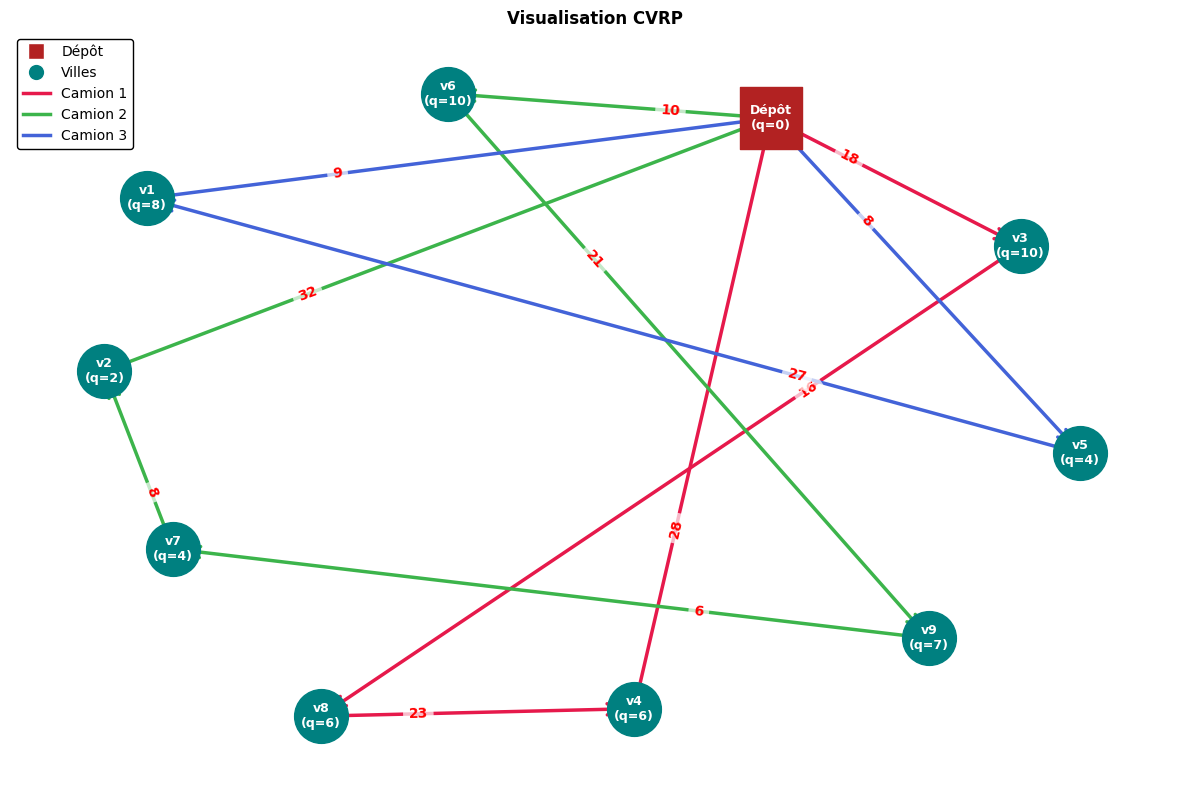

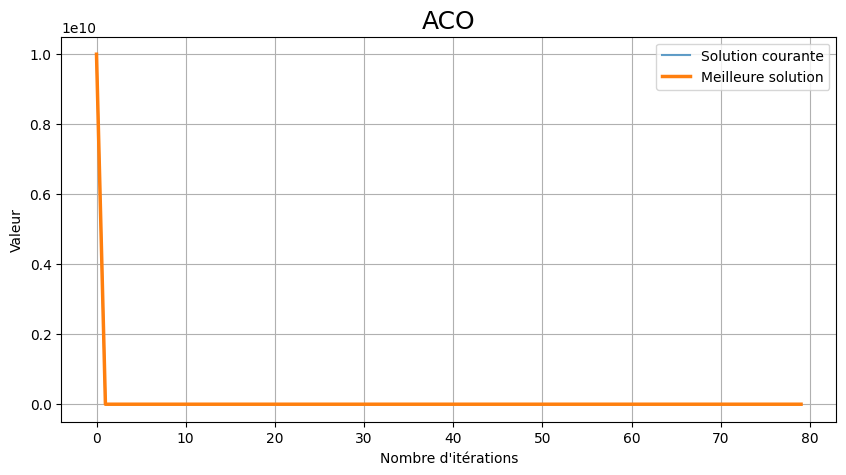

In [102]:



solution, dist, hist_c, hist_m = aco_cvrp(
    matrice, demandes, capacite_max, nb_vehicules,
    n_fourmis=20, n_iter=80,
    alpha=1.0, beta=3.0, rho=0.1, Q=100.0,
    historique=True,
)
afficher_resultats("MEILLEURE SOLUTION",solution, matrice, demandes, capacite_max)
visualiser_probleme(n, matrice, demandes,solution)
afficher_courbe(hist_c,hist_m, "ACO")

# 3 - Analyse comparative des algorithmes

Après avoir implémenté les trois approches (Recherche Tabou, Algorithme Génétique et Colonies de Fourmis), nous procédons à une analyse comparative pour déterminer la méthode la plus adaptée à notre problématique de transport durable.

L'évaluation repose sur deux indicateurs de performance clés (KPI) : la qualité de la solution (proximité avec l'optimum) et le coût computationnel (temps de calcul).


## 3.1 Qualité de la solution

In [98]:
def borne_inferieure(matrice, demandes, capacite_max, nb_vehicules):
    n = len(matrice) - 1
    villes = range(n + 1)
    vehicules = range(nb_vehicules)


    prob = LpProblem("CVRP_Exact", LpMinimize)


    x = LpVariable.dicts('x', (villes, villes, vehicules), 0, 1, LpContinuous)


    prob += lpSum([matrice[i][j] * x[i][j][k]
                   for i in villes for j in villes for k in vehicules if i != j])


    for j in range(1, n + 1):
        prob += lpSum([x[i][j][k] for i in villes for k in vehicules if i != j]) == 1


    for k in vehicules:
        for j in villes:
            prob += lpSum([x[i][j][k] for i in villes if i != j]) - \
                    lpSum([x[j][l][k] for l in villes if l != j]) == 0

    for k in vehicules:
        prob += lpSum([demandes[j] * x[i][j][k]
                       for i in villes for j in range(1, n + 1) if i != j]) <= capacite_max

    for k in vehicules:
        prob += lpSum([x[0][j][k] for j in range(1, n + 1)]) <= 1


    u = LpVariable.dicts('u', [i for i in range(1, n + 1)], 2, n + 1, LpContinuous)
    for k in vehicules:
        for i in range(1, n + 1):
            for j in range(1, n + 1):
                if i != j:
                    prob += u[i] - u[j] + (n + 1) * x[i][j][k] <= n

    prob.solve(PULP_CBC_CMD(msg=0))

    if LpStatus[prob.status] == "Optimal":
        return value(prob.objective)
    else:
        return None



borne = borne_inferieure(matrice, demandes, capacite_max,nb_vehicules)


Début du benchmark de précision...
Analyse de la précision pour n = 5...
--- Instance générée ---
Total colis à livrer : 25
Capacité par véhicule : 17
Génération 0 : Meilleure distance = 168
Génération 10 : Meilleure distance = 161
Génération 20 : Meilleure distance = 161
Génération 30 : Meilleure distance = 161
Génération 40 : Meilleure distance = 161
Génération 50 : Meilleure distance = 161
Génération 60 : Meilleure distance = 161
Génération 70 : Meilleure distance = 161
Génération 80 : Meilleure distance = 161
Génération 90 : Meilleure distance = 161
Génération 100 : Meilleure distance = 161
Génération 110 : Meilleure distance = 161
Génération 120 : Meilleure distance = 161
Génération 130 : Meilleure distance = 161
Génération 140 : Meilleure distance = 161
Analyse de la précision pour n = 10...
--- Instance générée ---
Total colis à livrer : 50
Capacité par véhicule : 39
Génération 0 : Meilleure distance = 233
Génération 10 : Meilleure distance = 222
Génération 20 : Meilleure distan

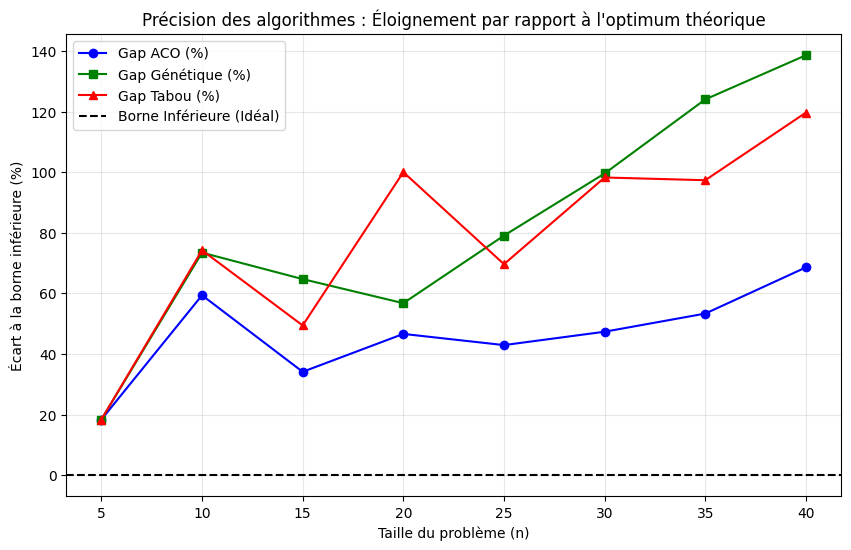

In [99]:
import matplotlib.pyplot as plt
from time import perf_counter

def benchmark_precision_cvrp(n_max):
    tailles = range(5, n_max, 5)

    gaps_aco = []
    gaps_genetique = []
    gaps_tabou = []

    print("Début du benchmark de précision...")

    tt = []
    for n in tailles:
        print(f"Analyse de la précision pour n = {n}...", end="\r")

        nb_v = max(2, n // 5)
        n, nb_v, matrice, demandes, capacite_max = generer_instance(n=n, nb_vehicules=nb_v)


        borne_inf = borne_inferieure(matrice, demandes, capacite_max, nb_v)

        if borne_inf is None:
            continue

        _, cout_aco = aco_cvrp(matrice, demandes, capacite_max, nb_v, n_fourmis=30, n_iter=100)
        gaps_aco.append(((cout_aco - borne_inf) / borne_inf) * 100)

        cout_gen = distance_total(algorithme_genetique(n, nb_v, matrice, demandes, capacite_max, taille_pop=100, generations=150)[0],matrice)
        gaps_genetique.append(((cout_gen - borne_inf) / borne_inf) * 100)


        sol_init = generer_random_solution(n, nb_v, demandes, capacite_max)

        sol_tabu = recherche_tabou(sol_init, matrice, demandes, capacite_max, taille_tabou=200, iter_max=2000)[0]
        cout_tabou = distance_total(sol_tabu,matrice)
        gaps_tabou.append(((cout_tabou - borne_inf) / borne_inf) * 100)

        tt.append(n)
        if gaps_tabou[-1] > 120 :
            gaps_tabou.pop()
            gaps_aco.pop()
            gaps_genetique.pop()
            tt.pop()
            break


    print(gaps_tabou)
    print(gaps_aco)
    print(gaps_genetique)
    plt.figure(figsize=(10, 6))
    plt.plot(tt, gaps_aco, label='Gap ACO (%)', marker='o', color='blue')
    plt.plot(tt, gaps_genetique, label='Gap Génétique (%)', marker='s', color='green')
    plt.plot(tt, gaps_tabou, label='Gap Tabou (%)', marker='^', color='red')

    plt.axhline(y=0, color='black', linestyle='--', label='Borne Inférieure (Idéal)')

    plt.xlabel('Taille du problème (n)')
    plt.ylabel('Écart à la borne inférieure (%)')
    plt.title('Précision des algorithmes : Éloignement par rapport à l\'optimum théorique')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

benchmark_precision_cvrp(50)

## 3.2 Coût computationnel

Début du benchmark...
Test pour n = 3...
--- Instance générée ---
Total colis à livrer : 15
Capacité par véhicule : 16
Génération 0 : Meilleure distance = 105
Génération 10 : Meilleure distance = 105
Génération 20 : Meilleure distance = 105
Génération 30 : Meilleure distance = 105
Génération 40 : Meilleure distance = 105
Test pour n = 4...
--- Instance générée ---
Total colis à livrer : 24
Capacité par véhicule : 29
Génération 0 : Meilleure distance = 105
Génération 10 : Meilleure distance = 105
Génération 20 : Meilleure distance = 105
Génération 30 : Meilleure distance = 105
Génération 40 : Meilleure distance = 105
Test pour n = 5...
--- Instance générée ---
Total colis à livrer : 37
Capacité par véhicule : 26
Génération 0 : Meilleure distance = 133
Génération 10 : Meilleure distance = 133
Génération 20 : Meilleure distance = 133
Génération 30 : Meilleure distance = 133
Génération 40 : Meilleure distance = 133
Test pour n = 6...
--- Instance générée ---
Total colis à livrer : 31
Capac

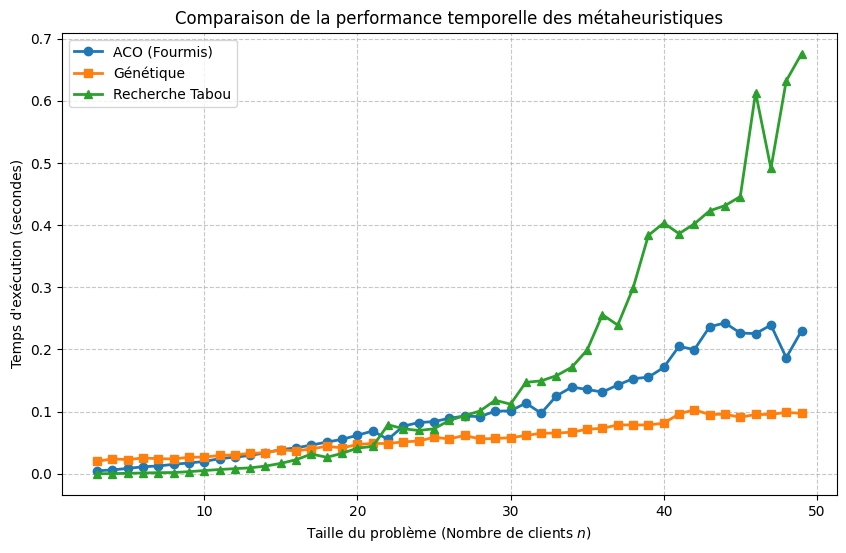

In [100]:
from time import perf_counter

def benchmark_cvrp(nb):

    tailles = range(3,nb)


    temps_aco = []
    temps_genetique = []
    temps_tabou = []

    print("Début du benchmark...")

    for n in tailles:
        print(f"Test pour n = {n}...", end="\r")

        nb_vehicules = max(2, n // 5)
        n, nb_v, matrice, demandes, capacite_max = generer_instance(n=n, nb_vehicules=nb_vehicules)

        t0 = perf_counter()
        aco_cvrp(matrice, demandes, capacite_max, nb_v, n_fourmis=20, n_iter=50)
        temps_aco.append(perf_counter() - t0)

        t1 = perf_counter()
        algorithme_genetique(n, nb_v, matrice, demandes, capacite_max, taille_pop=50, generations=50)
        temps_genetique.append(perf_counter() - t1)

        sol_init = generer_random_solution(n, nb_v, demandes, capacite_max)

        if sol_init is not None:
            t2 = perf_counter()
            recherche_tabou(sol_init, matrice, demandes, capacite_max, taille_tabou=10, iter_max=100)
            temps_tabou.append(perf_counter() - t2)
        else:

            temps_tabou.append(temps_tabou[-1] if temps_tabou else 0)

    plt.figure(figsize=(10, 6))
    plt.plot(tailles, temps_aco, label='ACO (Fourmis)', marker='o', linewidth=2)
    plt.plot(tailles, temps_genetique, label='Génétique', marker='s', linewidth=2)
    plt.plot(tailles, temps_tabou, label='Recherche Tabou', marker='^', linewidth=2)

    plt.xlabel('Taille du problème (Nombre de clients $n$)')
    plt.ylabel('Temps d\'exécution (secondes)')
    plt.title('Comparaison de la performance temporelle des métaheuristiques')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

benchmark_cvrp(50)

# Conclusion

Ce projet de recherche opérationnelle nous a permis de confronter trois approches majeures pour répondre aux défis de la logistique durable posés par l'ADEME. À travers la modélisation du CVRP et l'expérimentation algorithmique, nous avons pu identifier les forces et les limites de chaque méthode.
Synthèse des performances

L'étude comparative met en évidence deux profils algorithmiques distincts :

La Recherche Tabou s'impose comme la solution la plus rapide. Grâce à sa gestion efficace du voisinage et sa capacité à s'extraire des optima locaux avec un coût de calcul réduit, elle est idéale pour des prises de décision quasi instantanées ou des instances de taille modérée.

L'optimisation par Colonies de Fourmis (ACO) se distingue par sa précision supérieure. En simulant un comportement collectif d'exploration, cet algorithme parvient à identifier des routes plus optimales, réduisant davantage la distance totale parcourue par rapport aux autres méthodes. C'est l'outil le plus performant pour maximiser la réduction de l'empreinte carbone, au prix d'un temps d'exécution plus long.